# Business Case: 

This heart disease prediction aim to detect the presence or risk of heart disease in the person based on their medical attributes. For this, we use a representative data set that includes medical histories and attribute information for several patients. Moreover, data processing, exploratory data analysis, and some data visualization bring out new insights from a medical dataset. For example, using some data processing on our heart disease data, we saw how thalassemia was the most significant deciding factor in heart disease diagnosis. Medical experts can use data science to back their diagnosis, and even improve and hasten the treatment.

# Domain Analysis:

The given dataset contains data about Heart disease Prediction in total three data types i.e.,float,int,object.Mainly observe that the data is belongs to supervised domain.The attribute information regarding this dataset is:
- There are 14 columns in the dataset, where the patient_id column is a unique and random identifier. The remaining 13 features are described in the section below.
- slope_of_peak_exercise_st_segment (type: int): the slope of the peak exercise ST segment, an electrocardiography read out indicating quality of blood flow to the heart
- thal (type: categorical): results of thallium stress test measuring blood flow to the heart, with possible values normal, fixed_defect, reversible_defect
- resting_blood_pressure (type: int): resting blood prechest_pain_type (type: int): chest pain type (4 values)
- num_major_vessels (type: int): number of major vessels (0-3) colored by flourosopy
- fasting_blood_sugar_gt_120_mg_per_dl (type: binary): fasting blood sugar > 120 mg/dl
- resting_ekg_results (type: int): resting electrocardiographic results (values 0,1,2)
- serum_cholesterol_mg_per_dl (type: int): serum cholestoral in mg/dl
- oldpeak_eq_st_depression (type: float): oldpeak = ST depression induced by exercise relative to rest, a measure of abnormality in electrocardiograms
- sex (type: binary): 0: female, 1: male
- age (type: int): age in years
- max_heart_rate_achieved (type: int): maximum heart rate achieved (beats per minute)
- exercise_induced_angina (type: binary): exercise-induced chest pain (0: False, 1: True)
​
In order to proceed further we need to import the required libraries and packages regarding prediction of heart disease prediction

## Importing and Reading the data:

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import klib
from sklearn.svm import SVC
from sklearn import metrics
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler, MinMaxScaler
sc=StandardScaler()
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from pandas import Series, DataFrame
import warnings
warnings.filterwarnings('ignore')

In [2]:
df1=pd.read_csv('labels.csv')
df1

,patient_id,heart_disease_present
0,0z64un,0
1,ryoo3j,0
2,yt1s1x,1
3,l2xjde,1
4,oyt4ek,0
...,...,...
175,5qfar3,1
176,2s2b1f,1
177,nsd00i,1
178,0xw93k,0


In [3]:
df2=pd.read_csv('values.csv')
df2

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0


In [4]:
df=pd.merge(df1,df2)
df

,patient_id,heart_disease_present,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,0,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,0,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,0,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,1,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0
176,2s2b1f,1,2,normal,180,4,0,0,1,327,3.4,0,55,117,1
177,nsd00i,1,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1
178,0xw93k,0,1,normal,124,3,2,1,0,255,0.0,1,48,175,0


## Basic Checks:

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   heart_disease_present                 180 non-null    int64  
 2   slope_of_peak_exercise_st_segment     180 non-null    int64  
 3   thal                                  180 non-null    object 
 4   resting_blood_pressure                180 non-null    int64  
 5   chest_pain_type                       180 non-null    int64  
 6   num_major_vessels                     180 non-null    int64  
 7   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 8   resting_ekg_results                   180 non-null    int64  
 9   serum_cholesterol_mg_per_dl           180 non-null    int64  
 10  oldpeak_eq_st_depression              180 non-null    float64
 11  sex                

In [6]:
df.isnull().sum()

patient_id                              0
heart_disease_present                   0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df['heart_disease_present'].value_counts()

0    100
1     80
Name: heart_disease_present, dtype: int64

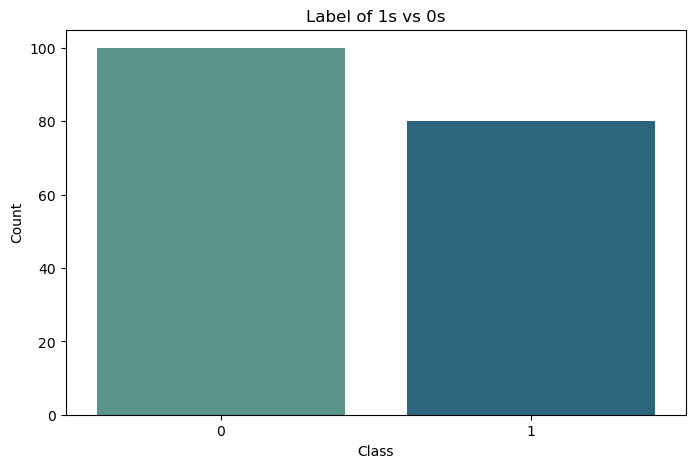

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(x='heart_disease_present',data=df,palette='crest')
plt.title('Label of 1s vs 0s')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

- The dataset is pretty balanced so we don't require balancing case in here.

## Cleansing the data using "Klib"

<AxesSubplot:xlabel='max_heart_rate_achieved', ylabel='Density'>

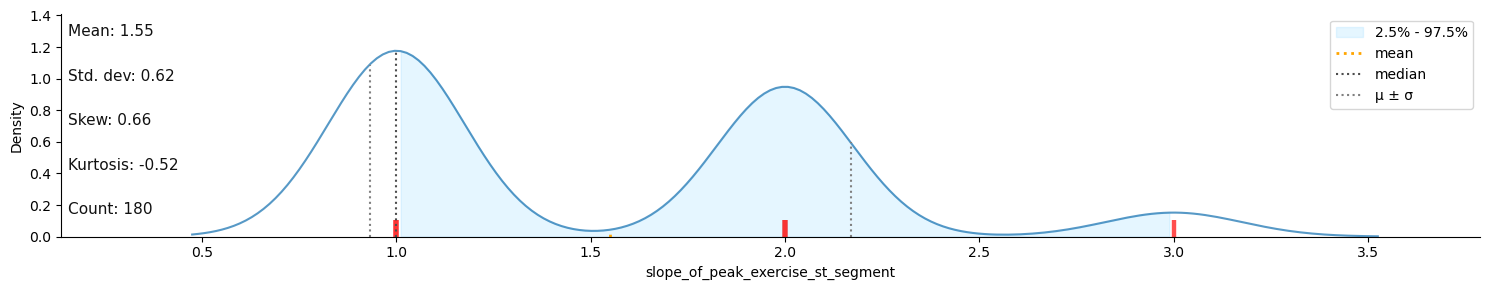

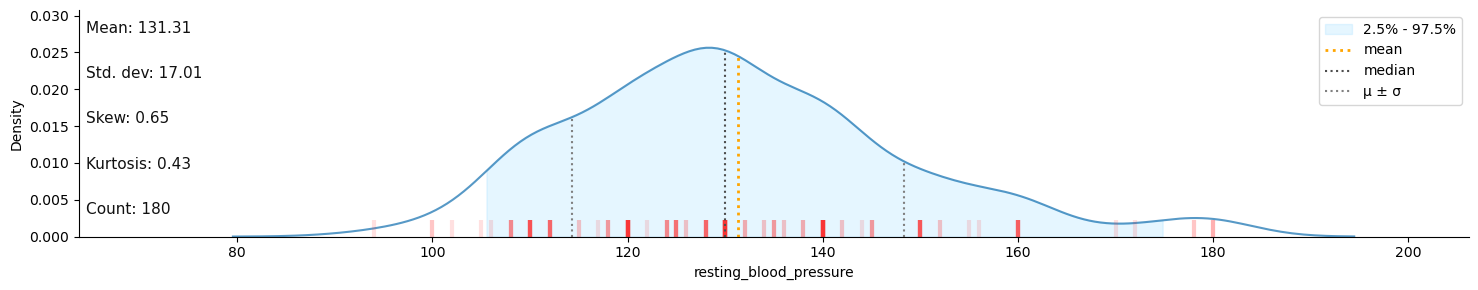

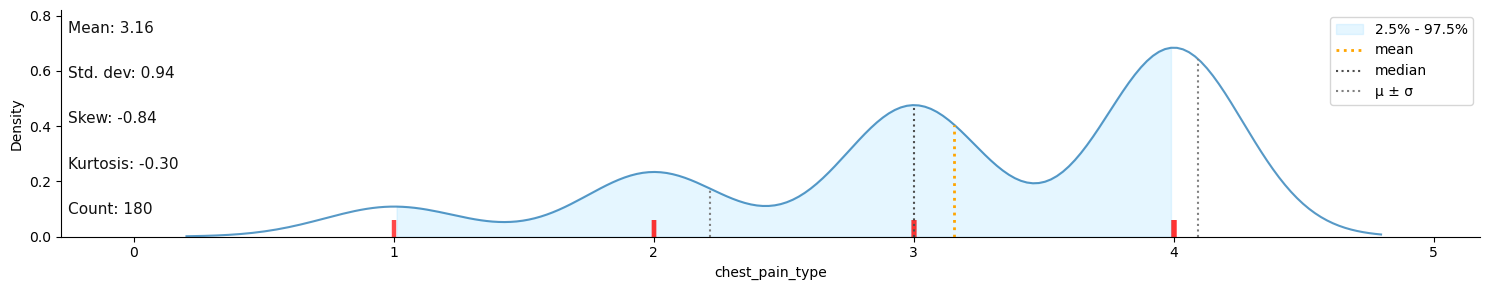

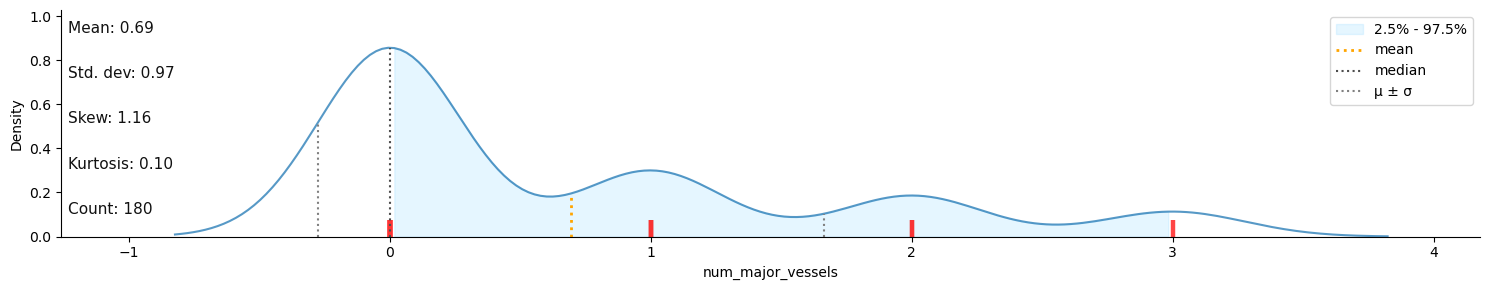

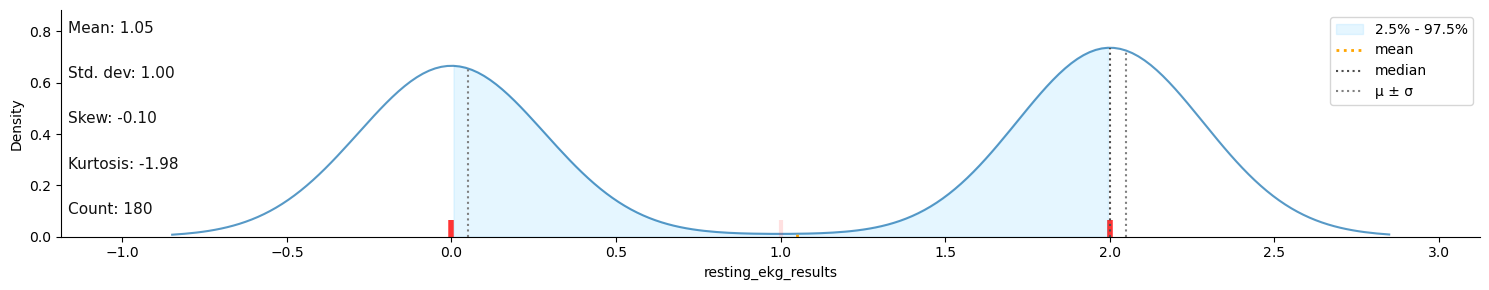

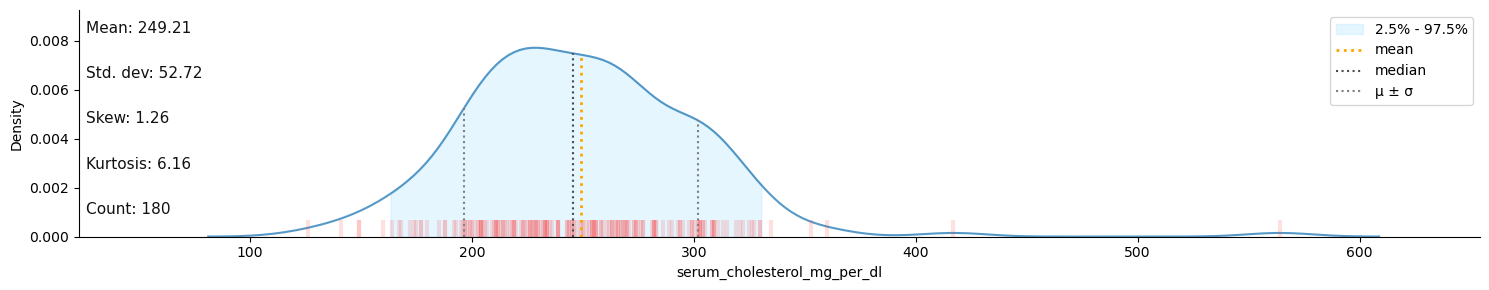

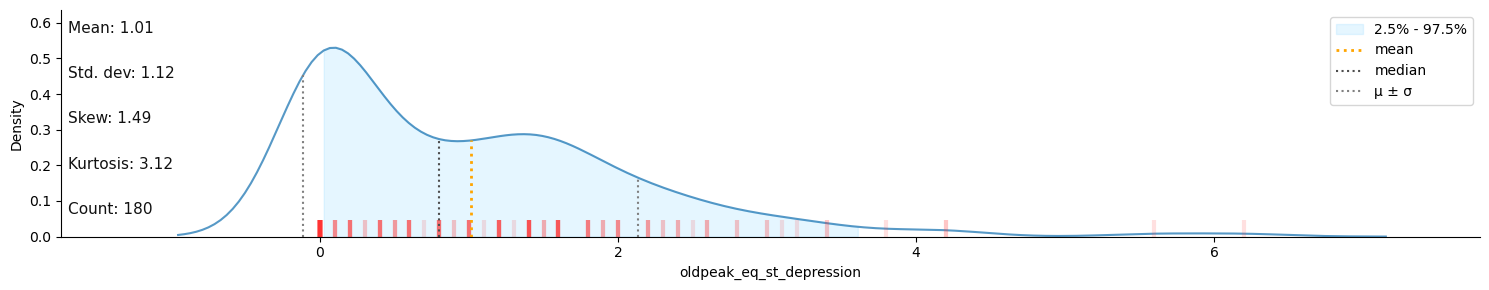

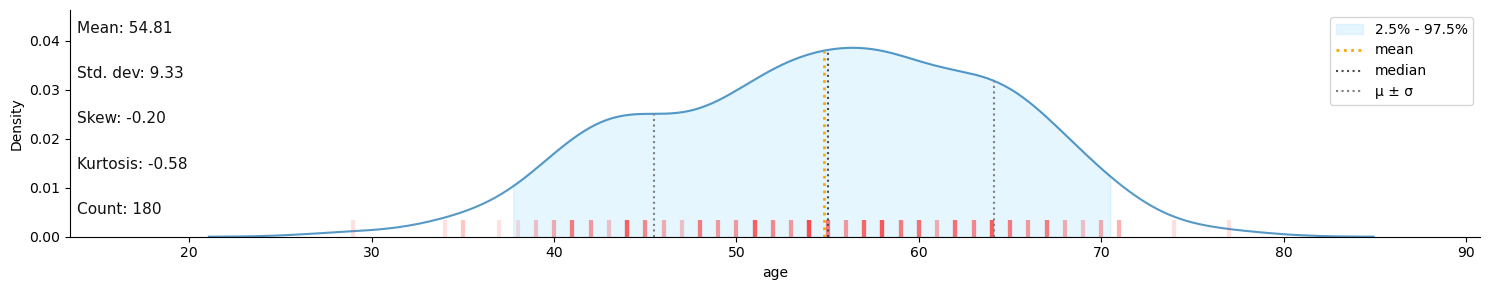

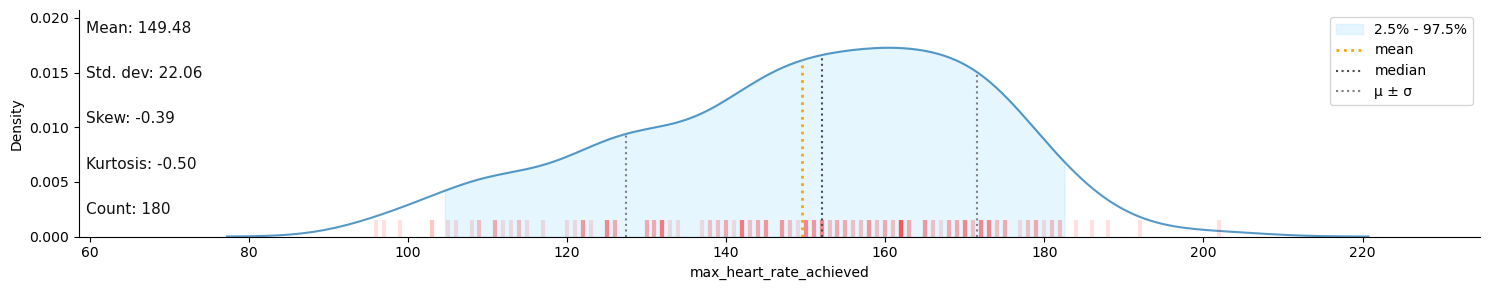

In [10]:
klib.dist_plot(df) # returns a distribution plot for every numeric feature

In [11]:
# klib.clean - functions for cleaning datasets
klib.data_cleaning(df) # performs datacleaning (drop duplicates & empty rows/cols, adjust dtypes,...)

Long column names detected (>25 characters). Consider renaming the following columns ['slope_of_peak_exercise_st_segment', 'fasting_blood_sugar_gt_120_mg_per_dl', 'serum_cholesterol_mg_per_dl'].
Shape of cleaned data: (180, 15) - Remaining NAs: 0


Dropped rows: 0
     of which 0 duplicates. (Rows (first 150 shown): [])

Dropped columns: 0
     of which 0 single valued.     Columns: []
Dropped missing values: 0
Reduced memory by at least: 0.02 MB (-66.67%)



,patient_id,heart_disease_present,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,0,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,0,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,0,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,1,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0
176,2s2b1f,1,2,normal,180,4,0,0,1,327,3.4,0,55,117,1
177,nsd00i,1,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1
178,0xw93k,0,1,normal,124,3,2,1,0,255,0.0,1,48,175,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   heart_disease_present                 180 non-null    int64  
 2   slope_of_peak_exercise_st_segment     180 non-null    int64  
 3   thal                                  180 non-null    object 
 4   resting_blood_pressure                180 non-null    int64  
 5   chest_pain_type                       180 non-null    int64  
 6   num_major_vessels                     180 non-null    int64  
 7   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 8   resting_ekg_results                   180 non-null    int64  
 9   serum_cholesterol_mg_per_dl           180 non-null    int64  
 10  oldpeak_eq_st_depression              180 non-null    float64
 11  sex                

- As the columns present in the data in here is big so we modify/rename them into smaller names 

In [13]:
## Renaming the columns
df.rename(columns={'slope_of_peak_exercise_st_segment':'slope','fasting_blood_sugar_gt_120_mg_per_dl':'fbs', 
                  'resting_blood_pressure':'restbps','chest_pain_type':'cp','resting_ekg_results':'restecg',
                  'serum_cholesterol_mg_per_dl':'chol','oldpeak_eq_st_depression':'oldpeak',
                  'exercise_induced_angina':'exang','max_heart_rate_achieved':'maxhrach'},inplace=True)

- As the 'patient_id' & 'num_major_vessels' doesn't affect the data so, we drop them in below. 

In [14]:
df.drop(columns={'patient_id','num_major_vessels'},inplace=True)

- As we know from info that 'thal' is in categorical data we convert it into numerical form by the process of Ordinal Encoding in below.

In [15]:
## Ordinal Encoding

dict={'normal':0,'reversible_defect':1,'fixed_defect':2}
df.thal=df.thal.map(dict)
df['thal'].value_counts()

0    98
1    74
2     8
Name: thal, dtype: int64

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 180 entries, 0 to 179
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   heart_disease_present  180 non-null    int64  
 1   slope                  180 non-null    int64  
 2   thal                   180 non-null    int64  
 3   restbps                180 non-null    int64  
 4   cp                     180 non-null    int64  
 5   fbs                    180 non-null    int64  
 6   restecg                180 non-null    int64  
 7   chol                   180 non-null    int64  
 8   oldpeak                180 non-null    float64
 9   sex                    180 non-null    int64  
 10  age                    180 non-null    int64  
 11  maxhrach               180 non-null    int64  
 12  exang                  180 non-null    int64  
dtypes: float64(1), int64(12)
memory usage: 23.8 KB


## Exploratory Data Analysis(EDA)

- Hence the basic checks are enquired and moves to the EDA(Exploratory Data Analysis)
- In general the EDA is exploring the data through the various types of plots i.e., Graphs
- There are Three types of Analysis for plots
    - 1.Uni-Variate Analysis:-It allows to check only one feature analysis at a time.
       - ex: Hist plot,Dist plot,Count plot,Box plot,RUG plot,Line plot...etc.
    - 2.Bi-Variate Analysis:-It allows to check two feature analysis at a time.
       - ex: Scatter plot ,Line plot, Box plot,...etc.
    - 3.Multivariate Analysis:-It allows to check whole data at a time.
       - ex: Heat map, Pair plot,..etc.

## Univariate Analysis

In general box plot is used for both uni and bi variate analysis.

Here in order to detect the outliers we used boxplot.

The plots used for UNI-VARIATE analysis are :

- Box plot
- Count plot
- Rug plot
- Hist plot

## Count plot

- It is a method used to show the count of observations in each bin using bars

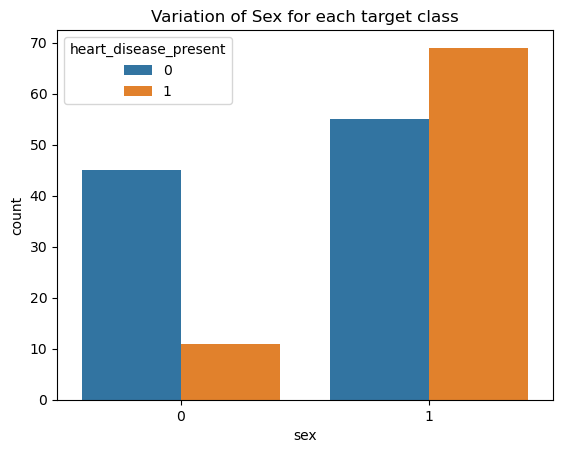

In [17]:
# distribution of target vs age 
sns.set_context() 
sns.countplot( data = df, x = 'sex',hue = 'heart_disease_present')
plt.title('Variation of Sex for each target class')
plt.show()

- We can conclude that Males are most likely to get attacked to heart disease compared to females

### Catplot

Used to create figure-level relational plots onto a Seaborn Facetgrid

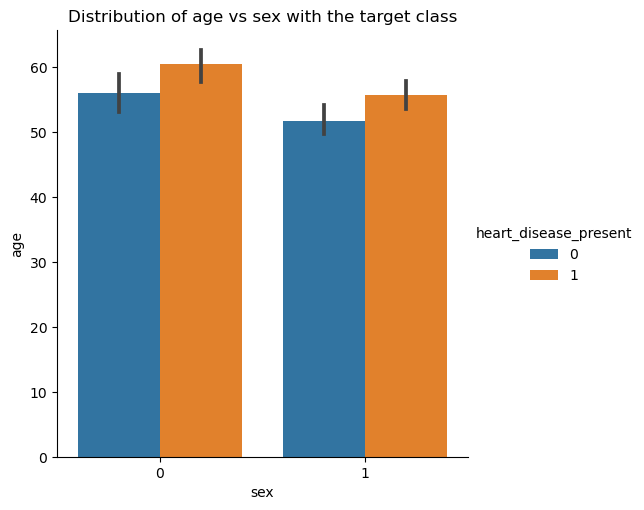

In [18]:
# barplot of age vs sex with hue = target
sns.catplot(kind = 'bar', data = df, y = 'age', x = 'sex', hue = 'heart_disease_present')
plt.title('Distribution of age vs sex with the target class')
plt.show()

- Females with age of 57 and above are prone of attacking heart disease
- Males with the age of 53 and above are prone of attacking heart disease
- We can conclude that Males of age 50 and above are most likely to get attacked compared to females

- From the bar plot Analysis it implies the different kinds of age group.
- The majority case of males effecting from the heart disease lying between the 55-60 year.Moreover, in non heart effecting conditon with the range of mens is (60+) years of age.
- Now females are least in both condition with effected heart  disease with the ages of 50-55 .Eventhough, none else conditon of heart rate with the age of (55+)

### BIVARIATE ANALYSIS :
- In general the Bivariate anlaysis known as Distinguish between the two features at a time. 
- Selection of two features  by visualising in box plot using the data,It shows  the relation of heart disease present and max heart rate achieved 

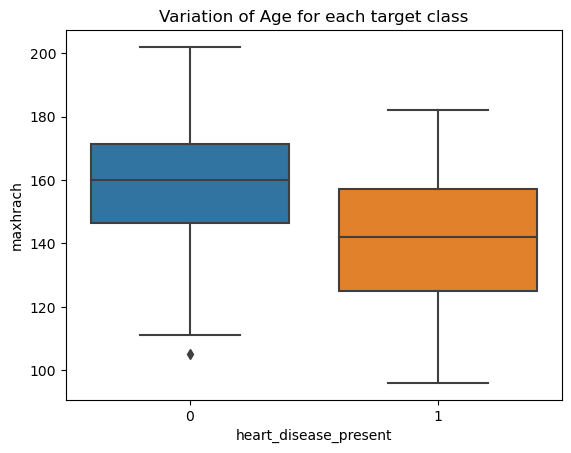

In [19]:
sns.boxplot(x = 'heart_disease_present',y='maxhrach',data=df)
plt.title('Variation of Age for each target class')
plt.show()

- From the below box plot analysis we concluded that  the percentage of having heart disease are having a range of (140,180) max_heart_rate.
- For non else heart disease people lying the range of(120,160) max_heart_rate.

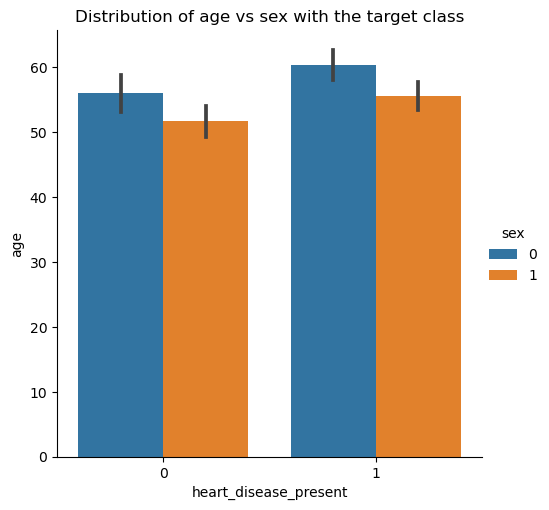

In [20]:
# barplot of age vs sex with hue = target
sns.catplot(kind = 'bar', data = df, y = 'age', x = 'heart_disease_present', hue = 'sex')
plt.title('Distribution of age vs sex with the target class')
plt.show()

In [21]:
df.isnull().sum()

heart_disease_present    0
slope                    0
thal                     0
restbps                  0
cp                       0
fbs                      0
restecg                  0
chol                     0
oldpeak                  0
sex                      0
age                      0
maxhrach                 0
exang                    0
dtype: int64

## Data preprocessing

- In general the process of data preprocessing is cleaning the dataset(clearing null values)
- The process involed in data preprocessing was :
    - Handling with null vales
    - Encoding
    - Handling with outliers
    - Scaling

## Outliers handling

- Data points that are significantly different from the rest of the dataset.

    
## Box plot

- It is a type of chart that depicts a group of numerical data through their quartiles.
- It is a simple way to visualize the shape of our data.
- It makes comparing characteristics of data between categories very easy.

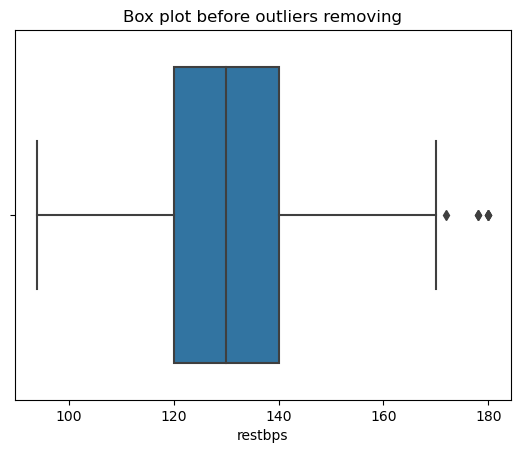

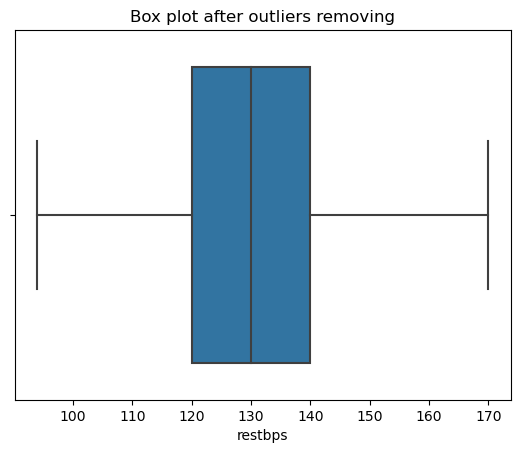

In [22]:
sns.boxplot(df['restbps'])
plt.title('Box plot before outliers removing')
plt.show()

def drop_outliers(df,restbps):
    iqr=1.5*(np.percentile(df['restbps'],75)-np.percentile(df['restbps'],25))
    df.drop(df[df['restbps']>(iqr+np.percentile(df['restbps'],75))].index,inplace=True)
    df.drop(df[df['restbps']<(np.percentile(df['restbps'],25)-iqr)].index,inplace=True)
    
drop_outliers(df,'restbps')
sns.boxplot(df['restbps'])
plt.title('Box plot after outliers removing')
plt.show()

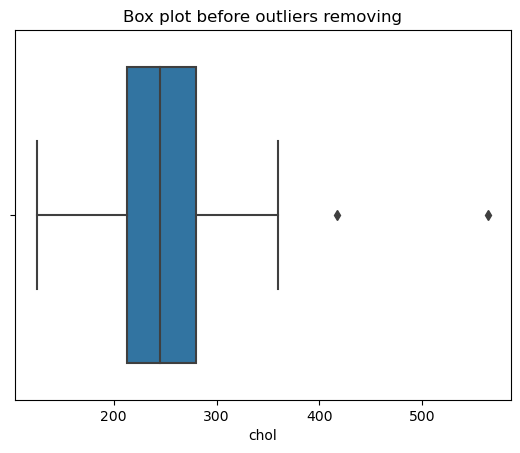

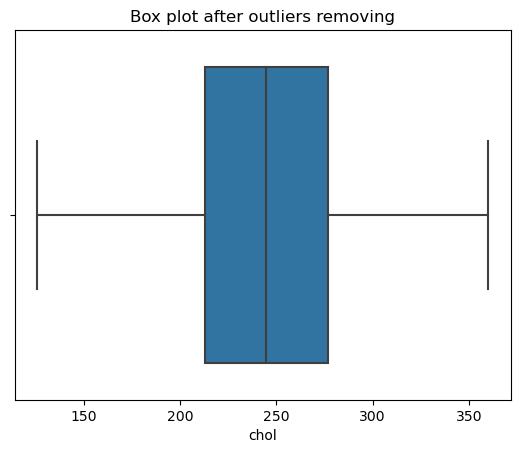

In [23]:
sns.boxplot(df['chol'])
plt.title('Box plot before outliers removing')
plt.show()

def drop_outliers(df,chol):
    iqr=1.5*(np.percentile(df['chol'],75)-np.percentile(df['chol'],25))
    df.drop(df[df['chol']>(iqr+np.percentile(df['chol'],75))].index,inplace=True)
    df.drop(df[df['chol']<(np.percentile(df['chol'],25)-iqr)].index,inplace=True)
    
drop_outliers(df,'chol')
sns.boxplot(df['chol'])
plt.title('Box plot after outliers removing')
plt.show()

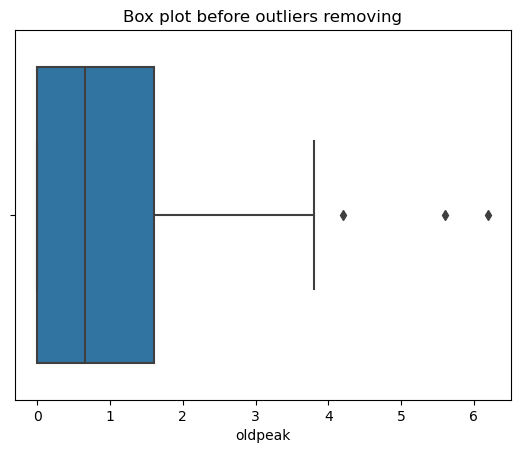

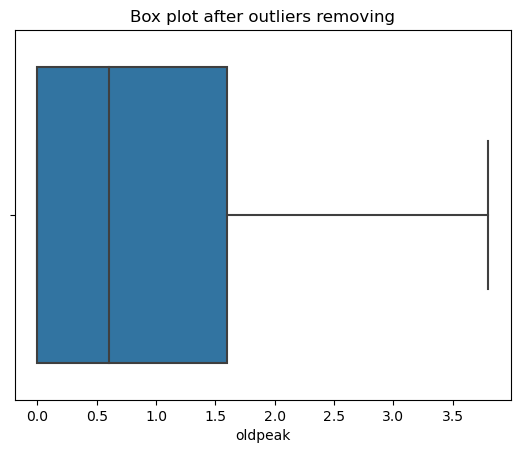

In [24]:
sns.boxplot(df['oldpeak'])
plt.title('Box plot before outliers removing')
plt.show()

def drop_outliers(df,oldpeak):
    iqr=1.5*(np.percentile(df['oldpeak'],75)-np.percentile(df['oldpeak'],25))
    df.drop(df[df['oldpeak']>(iqr+np.percentile(df['oldpeak'],75))].index,inplace=True)
    df.drop(df[df['oldpeak']<(np.percentile(df['oldpeak'],25)-iqr)].index,inplace=True)
    
drop_outliers(df,'oldpeak')
sns.boxplot(df['oldpeak'])
plt.title('Box plot after outliers removing')
plt.show()

<AxesSubplot:>

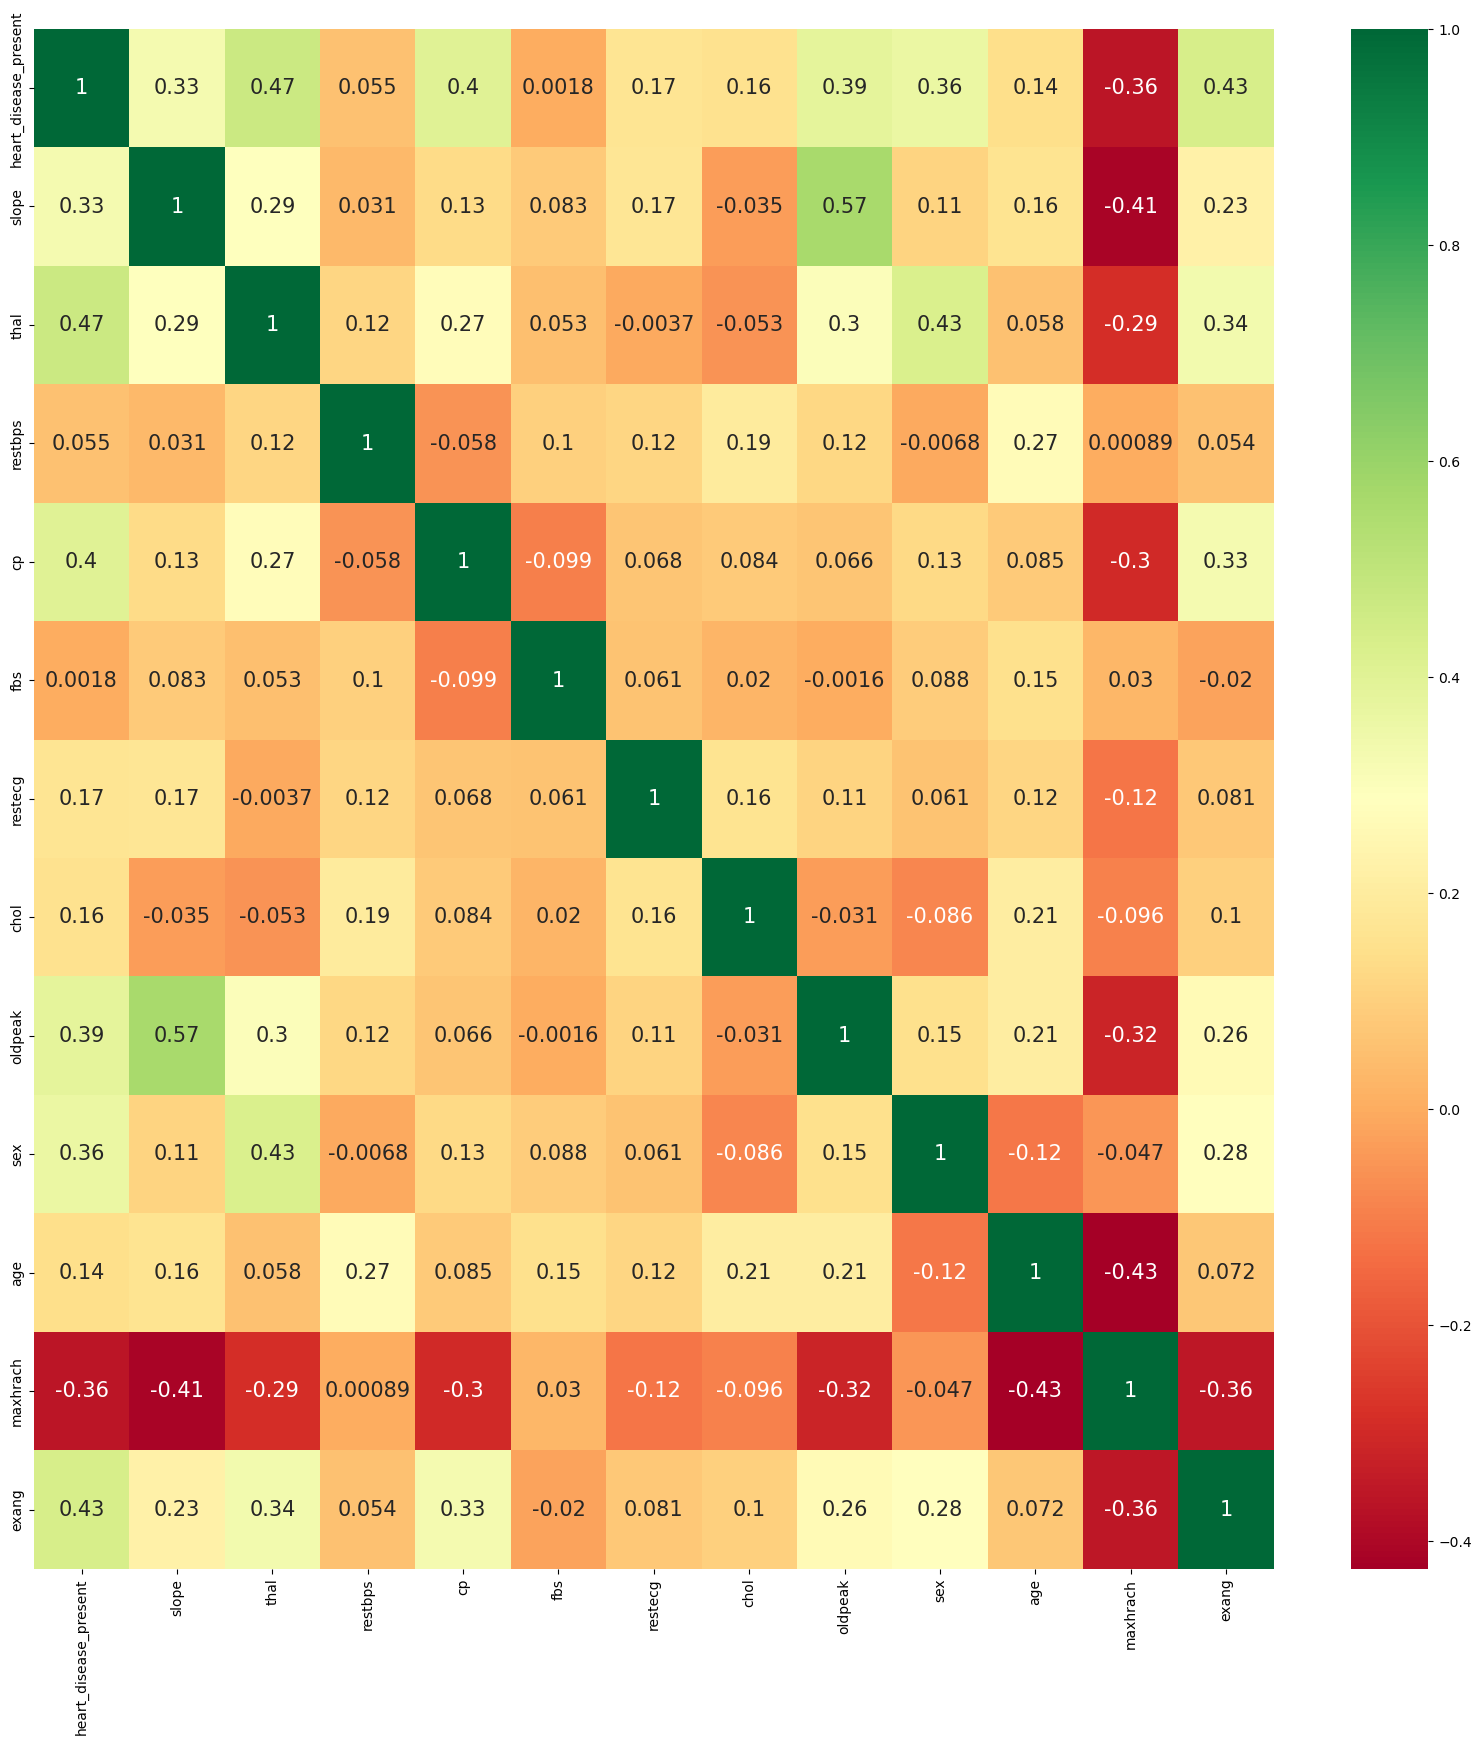

In [25]:
## Checking correlation

plt.figure(figsize=(20, 20))#canvas size
sns.heatmap(df.corr(), annot=True, cmap="RdYlGn", annot_kws={"size":15})#plotting heat map to check correlation

- Heat map is a graphical representation of data where the indvidual scores are represented in a matrix form although, it shows    in a colors
- Above the heat map  analysis using parameters  of correlation,Cmap as well as,Annotation
- In Cmap mainly specifies the color here we have taken as RdYlGn(Red,Yellow,Green) for the heat map.
- Rd:Negative correlation,Yl: Moderate, Gn: Strong correlation.
- After analysis of  above the heat map we have concluded that maxhrach row has shows the weak correaltion with respective of red color whereas,heart_disease_present having a strong  correlation in Green.
- Annotation is used for displaying the values in a heat map.

In [26]:
## Exp-1
df3=df.copy()
df3.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 169 entries, 0 to 179
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   heart_disease_present  169 non-null    int64  
 1   slope                  169 non-null    int64  
 2   thal                   169 non-null    int64  
 3   restbps                169 non-null    int64  
 4   cp                     169 non-null    int64  
 5   fbs                    169 non-null    int64  
 6   restecg                169 non-null    int64  
 7   chol                   169 non-null    int64  
 8   oldpeak                169 non-null    float64
 9   sex                    169 non-null    int64  
 10  age                    169 non-null    int64  
 11  maxhrach               169 non-null    int64  
 12  exang                  169 non-null    int64  
dtypes: float64(1), int64(12)
memory usage: 18.5 KB


- The basics of feature engineering and data science tell us that such columns need to be encoded to avoid unintentional bias. For example, as shown below, columns like chest pain (cp), thal need to be dummy encoded in addition to others.

- Moreover, the columns of age, cholesterol (chol), Rest BP (restbps), maxhrach, and oldpeak need to be normalized.

- We achieve these tasks using Pandas and the StandardScaler module from sklearn. In addition to that, we must also perform a check for missing values and make sure we have a numeric target variable.

In [27]:
df3=pd.get_dummies(df3,columns=['slope','thal','cp','fbs','restecg','sex','exang'])
from sklearn.preprocessing import StandardScaler
sc= StandardScaler()
columns_to_scale=['age','restbps','chol','oldpeak','maxhrach']
df3[columns_to_scale]=sc.fit_transform(df3[columns_to_scale])

- And below, we see a limited subset of the attributes we encoded and scaled. For instance, the chest pain data variable expanded into cp_0, cp_1, cp_2, and cp_3. This normalized and engineered dataset will be appropriate for training.

In [28]:
df3.head()

,heart_disease_present,restbps,chol,oldpeak,age,maxhrach,slope_1,slope_2,slope_3,thal_0,...,cp_3,cp_4,fbs_0,fbs_1,restecg_0,restecg_2,sex_0,sex_1,exang_0,exang_1
0,0,-0.096702,1.378097,-0.968550,-1.008162,0.909648,1,0,0,1,...,0,0,1,0,0,1,0,1,1,0
1,0,-1.317319,-0.711475,0.746551,-0.047978,0.368819,0,1,0,1,...,1,0,1,0,1,0,1,0,1,0
2,1,-0.300139,1.289179,-0.968550,2.405826,0.549096,1,0,0,1,...,0,1,1,0,0,1,0,1,0,1
3,1,1.530787,-0.511410,-0.968550,-1.541597,1.405407,1,0,0,0,...,0,1,1,0,1,0,0,1,1,0
5,0,0.038922,-1.467278,-0.968550,-1.328223,0.008267,1,0,0,1,...,1,0,1,0,1,0,0,1,1,0


### Predictor and Target Separation

In [29]:
X=df3.drop(columns='heart_disease_present', axis=1)
y=df3['heart_disease_present']

In [30]:
X

,restbps,chol,oldpeak,age,maxhrach,slope_1,slope_2,slope_3,thal_0,thal_1,...,cp_3,cp_4,fbs_0,fbs_1,restecg_0,restecg_2,sex_0,sex_1,exang_0,exang_1
0,-0.096702,1.378097,-0.968550,-1.008162,0.909648,1,0,0,1,0,...,0,0,1,0,0,1,0,1,1,0
1,-1.317319,-0.711475,0.746551,-0.047978,0.368819,0,1,0,1,0,...,1,0,1,0,1,0,1,0,1,0
2,-0.300139,1.289179,-0.968550,2.405826,0.549096,1,0,0,1,0,...,0,1,1,0,0,1,0,1,0,1
3,1.530787,-0.511410,-0.968550,-1.541597,1.405407,1,0,0,0,1,...,0,1,1,0,1,0,0,1,1,0
5,0.038922,-1.467278,-0.968550,-1.328223,0.008267,1,0,0,1,0,...,1,0,1,0,1,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,0.717042,-0.155738,0.317776,-0.047978,0.458957,1,0,0,1,0,...,0,1,1,0,1,0,0,1,1,0
175,-0.300139,0.177704,-0.754162,1.338955,0.594165,0,1,0,0,1,...,0,1,0,1,1,0,0,1,1,0
177,-0.300139,1.400327,0.960939,1.018894,-0.848045,0,1,0,0,1,...,1,0,1,0,1,0,0,1,0,1
178,-0.367951,0.199934,-0.968550,-0.688100,1.134993,1,0,0,1,0,...,1,0,0,1,1,0,0,1,1,0


In [31]:
y

0      0
1      0
2      1
3      1
5      0
      ..
174    0
175    1
177    1
178    0
179    0
Name: heart_disease_present, Length: 169, dtype: int64

### Train Test Split

In [32]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X, y)

In [33]:
X_train.shape

(126, 23)

In [34]:
X_test.shape

(43, 23)

### KNeighborsClassifier

- Using the KNeighborsClassifier module from sklearn, we build a KNN model and iteratively tune the hyperparameter n_neighbors (number of neighbours to be checked for every data point).

In [35]:
knn_scores=[]
for k in range(1,40):
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)
    knn_scores.append(knn.score(X_test,y_test))

print(f'Best choice of k:{np.argmax(knn_scores)+1}')

Best choice of k:36


In [36]:
k=2
knn=KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train,y_train)
y_pred1=knn.predict(X_test)
accuracy_score(y_pred1,y_test)

0.7674418604651163

We see that the best choice of n_neighbors is 2, and the accuracy of this model is around 81.4%

- As we noted earlier, the K neighbors classifier is very efficient and would be pretty helpful our smaller and simpler dataset. With around 300 samples and binary classification, KNN was robustly able to distinguish between the two classes and performs well on speed and accuracy.

In [37]:
from sklearn.metrics import classification_report,f1_score
print(classification_report(y_pred1,y_test))

              precision    recall  f1-score   support

           0       0.96      0.74      0.83        34
           1       0.47      0.89      0.62         9

    accuracy                           0.77        43
   macro avg       0.72      0.81      0.72        43
weighted avg       0.86      0.77      0.79        43



In [38]:
y_hat1=knn.predict(X_test)
f1_score(y_test,y_hat1)

0.6153846153846153

In [39]:
## checking cross validation score
from sklearn.model_selection import cross_val_score
scores = cross_val_score(knn,X,y,cv=3, scoring = 'f1')
print(scores)
print("Cross validation Score:",scores.mean())
print("Std :",scores.std())
#std of < 0.05 is good. 

[0.65       0.66666667 0.66666667]
Cross validation Score: 0.6611111111111111
Std : 0.007856742013183808


## Naive_bayes

In [40]:
from sklearn.naive_bayes import GaussianNB  
nb = GaussianNB()  
nb.fit(X_train, y_train)

GaussianNB()

In [41]:
from sklearn.metrics import accuracy_score
y_pred2=nb.predict(X_test)
accuracy_score(y_pred2,y_test)

0.7209302325581395

In [42]:
from sklearn.metrics import classification_report
print(classification_report(y_pred2,y_test))

              precision    recall  f1-score   support

           0       0.73      0.79      0.76        24
           1       0.71      0.63      0.67        19

    accuracy                           0.72        43
   macro avg       0.72      0.71      0.71        43
weighted avg       0.72      0.72      0.72        43



In [43]:
y_hat2=nb.predict(X_test)
f1_score(y_test,y_hat2)

0.6666666666666667

In [44]:
## checking cross validation score
from sklearn.model_selection import cross_val_score
scores = cross_val_score(nb,X,y,cv=3, scoring = 'f1')
print(scores)
print("Cross validation Score:",scores.mean())
print("Std :",scores.std())
#std of < 0.05 is good. 

[0.72340426 0.83333333 0.67857143]
Cross validation Score: 0.7451030057413036
Std : 0.06501763155122076


## SVM

The svm.SVC function in sklearn has several hyperparameters. We explore the primary ones: choice of kernel, regularization, and degree of the polynomial kernel.

In [45]:
from sklearn.svm import SVC
svc_scores=[]
kernels=['linear','poly','rbf','sigmoid']

for i in range(len(kernels)):
    svc=SVC(kernel=kernels[i])
    svc.fit(X_train,y_train)
    svc_scores.append(svc.score(X_test,y_test))
    
print(f'Best choice:{np.argmax(svc_scores)+1}')

Best choice:3


- We find that the best kernel choice is 'poly', and the regularization parameter must be 1.0. This choice of hyperparameters gives 70% accuracy on the test set. This is in line with the theoretical understanding of SVM -- with a large dimension of features and binary classes, the hyperplane creation has much flexibility to get decent performance. However, a higher number of samples during training might help the SVM model to perform better.

In [46]:
svc=SVC(kernel='rbf')
svc.fit(X_train,y_train)
y_pred3=svc.predict(X_test)
accuracy_score(y_pred3,y_test)

0.7674418604651163

In [47]:
from sklearn.metrics import classification_report
print(classification_report(y_pred3,y_test))

              precision    recall  f1-score   support

           0       0.77      0.83      0.80        24
           1       0.76      0.68      0.72        19

    accuracy                           0.77        43
   macro avg       0.77      0.76      0.76        43
weighted avg       0.77      0.77      0.77        43



In [48]:
y_hat3=svc.predict(X_test)
f1_score(y_test,y_hat3)

0.7222222222222222

In [49]:
## checking cross validation score
from sklearn.model_selection import cross_val_score
scores = cross_val_score(svc,X,y,cv=3, scoring = 'f1')
print(scores)
print("Cross validation Score:",scores.mean())
print("Std :",scores.std())
#std of < 0.05 is good. 

[0.7755102  0.7826087  0.70175439]
Cross validation Score: 0.7532910952329063
Std : 0.036557000672689806


### Decision tree

Similar to SVC, the DecisionTreeClassifier module of sklearn has two primary hyperparameters to select: choice of splitting criterion and the maximum number of features to build a tree on. We tune them both iteratively and find that the Gini index is the best criterion for our dataset.

In [50]:
from sklearn.tree import DecisionTreeClassifier

dt_scores=[]
cr_scores=[]
for cr in ['gini','entropy']:
    for i in range(1,len(X.columns)+1):
        dt_classifier=DecisionTreeClassifier(criterion=cr, max_features=i,random_state=42)
        dt_classifier.fit(X_train, y_train)
        dt_scores.append(dt_classifier.score(X_test,y_test))
    print(f'Best max features of {cr}:{np.argmax(dt_scores)+1}')
    cr_scores.append(dt_scores[np.argmax(dt_scores)])

print(f'Best criterion:{"gini" if not np.argmax(cr_scores) else "entropy"}')

Best max features of gini:22
Best max features of entropy:22
Best criterion:gini


- Again, we find that the decision tree was not as robust as the K neighbors classifier or even SVM giving a test accuracy of only 81.4% in predicting the presence of heart diseases. While decision trees tend to overfit, techniques like bootstrapping, k-fold cross-validation, and gradient boosting might help improve the test accuracy. Even Random forests would help generally. But, Lower accuracy in the decision tree might signal a not a significant performance gain in the random forest classifier. Let's try that next.

In [51]:
dt_classifier=DecisionTreeClassifier(criterion='entropy',random_state=42)
dt_classifier.fit(X_train, y_train)
print(dt_classifier.score(X_test,y_test))

0.6976744186046512


In [52]:
y_pred4=dt_classifier.predict(X_test)
accuracy_score(y_pred4,y_test)

0.6976744186046512

In [53]:
print(classification_report(y_pred4,y_test))

              precision    recall  f1-score   support

           0       0.73      0.76      0.75        25
           1       0.65      0.61      0.63        18

    accuracy                           0.70        43
   macro avg       0.69      0.69      0.69        43
weighted avg       0.70      0.70      0.70        43



In [54]:
y_hat4=svc.predict(X_test)
f1_score(y_test,y_hat4)

0.7222222222222222

In [55]:
## checking cross validation score
from sklearn.model_selection import cross_val_score
scores = cross_val_score(dt_classifier,X,y,cv=3, scoring = 'f1')
print(scores)
print("Cross validation Score:",scores.mean())
print("Std :",scores.std())
#std of < 0.05 is good. 

[0.64285714 0.58823529 0.62745098]
Cross validation Score: 0.619514472455649
Std : 0.022994603839448617


[Text(0.5431034482758621, 0.9285714285714286, 'X[9] <= 0.5\nentropy = 0.993\nsamples = 126\nvalue = [69, 57]'),
 Text(0.3448275862068966, 0.7857142857142857, 'X[3] <= 0.432\nentropy = 0.742\nsamples = 76\nvalue = [60, 16]'),
 Text(0.20689655172413793, 0.6428571428571429, 'X[0] <= -0.707\nentropy = 0.463\nsamples = 51\nvalue = [46, 5]'),
 Text(0.13793103448275862, 0.5, 'X[19] <= 0.5\nentropy = 0.837\nsamples = 15\nvalue = [11, 4]'),
 Text(0.10344827586206896, 0.35714285714285715, 'X[18] <= 0.5\nentropy = 0.918\nsamples = 6\nvalue = [2, 4]'),
 Text(0.06896551724137931, 0.21428571428571427, 'X[0] <= -1.317\nentropy = 0.918\nsamples = 3\nvalue = [2, 1]'),
 Text(0.034482758620689655, 0.07142857142857142, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.10344827586206896, 0.07142857142857142, 'entropy = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.13793103448275862, 0.21428571428571427, 'entropy = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.1724137931034483, 0.35714285714285715, 'entrop

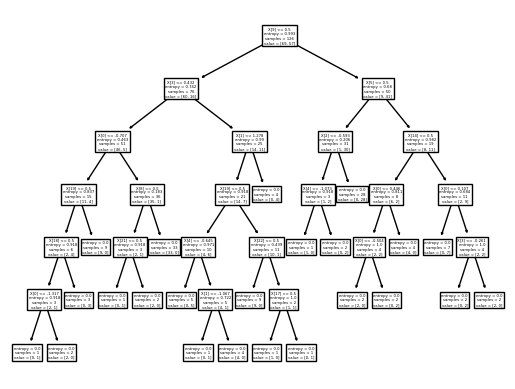

In [56]:
from sklearn import tree
tree.plot_tree(dt_classifier)

### Random Forest

- With random forest, we shall try a different method of choosing hyperparameters. Fortunately, scikit-learn has an in-built module for organized hyperparameter search called RandomizedSearchCV which takes in a range of hyperparameter choices, tests them alongwith cross-validation on the training set, and gives out the best choice. Once we define parameters, our search for the most optimal set becomes more straightforward and comprehensive than doing it iteratively and manually.

We are only tuning the n_estimators parameter on a tree level.

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

In [58]:
rfc_param_grid={
    'n_estimators':range(1,1000,10),
              }
rfc = RandomForestClassifier()

rfc_random=RandomizedSearchCV(param_distributions=rfc_param_grid,estimator=rfc,scoring='accuracy',verbose=0,n_iter=100,cv=4,
                             random_state=42)
rfc_random.fit(X_train, y_train)
best_params=rfc_random.best_params_
print(f'Best parameters:{best_params}')

Best parameters:{'n_estimators': 51}


- With the choice of 1000 estimators, our random forest classifier gives around 76.8% accuracy on the test set. Additional data or feature selection might help the performance. For the former, we can use the inbuilt feature_importances_ attribute of the sklearn model to rank the features from the most significant to the least for a specific model.

In [59]:
rfc=RandomForestClassifier(n_estimators= 911)
rfc.fit(X_train, y_train)
print(rfc.score(X_test,y_test))

0.7209302325581395


In [60]:
y_pred5=rfc.predict(X_test)
accuracy_score(y_pred5,y_test)

0.7209302325581395

In [61]:
print(classification_report(y_pred5,y_test))

              precision    recall  f1-score   support

           0       0.77      0.77      0.77        26
           1       0.65      0.65      0.65        17

    accuracy                           0.72        43
   macro avg       0.71      0.71      0.71        43
weighted avg       0.72      0.72      0.72        43



In [62]:
y_hat5=rfc.predict(X_test)
f1_score(y_test,y_hat5)

0.6470588235294118

In [63]:
## checking cross validation score
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rfc,X,y,cv=3, scoring = 'f1')
print(scores)
print("Cross validation Score:",scores.mean())
print("Std :",scores.std())
#std of < 0.05 is good. 

[0.76595745 0.71428571 0.65454545]
Cross validation Score: 0.7115962052132265
Std : 0.0455234964920612


- For our random forest model, thalasemia is the most critical feature by a significant margin compared to the rest. This might guide us for the selection of future datasets and the data gathering stage during the creation of such datasets. Identifying these would also help curate a more comprehensive and valuable dataset for heart disease detection.

In [64]:
## XGBoost Classifier

In [65]:
from xgboost import XGBClassifier#importing the model library
xgbc=XGBClassifier() ## object creation
xgbc.fit(X_train, y_train)# fitting the data

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)

In [66]:
y_pred6=xgbc.predict(X_test)
accuracy_score(y_pred6,y_test)

0.7209302325581395

In [67]:
print(classification_report(y_pred6,y_test))

              precision    recall  f1-score   support

           0       0.77      0.77      0.77        26
           1       0.65      0.65      0.65        17

    accuracy                           0.72        43
   macro avg       0.71      0.71      0.71        43
weighted avg       0.72      0.72      0.72        43



In [68]:
y_hat6=xgbc.predict(X_test)
f1_score(y_test,y_hat6)

0.6470588235294118

In [69]:
## checking cross validation score
from sklearn.model_selection import cross_val_score
scores = cross_val_score(xgbc,X,y,cv=3, scoring = 'f1')
print(scores)
print("Cross validation Score:",scores.mean())
print("Std :",scores.std())
#std of < 0.05 is good. 

[0.73913043 0.71111111 0.64150943]
Cross validation Score: 0.6972503266186614
Std : 0.04104108478383614


## Hyperparameter Tuning

- It consists of finding a set of optimal hyper parameter values for a learning alogorithm while applying this optimized algorithm to any dataset.

In [70]:
## DecisionTreeClassifier

In [71]:
params={'max_depth':range(1,1000,10),'criterion':['gini','entropy']}  
dtc=RandomizedSearchCV(DecisionTreeClassifier(),param_distributions=params,verbose=2,random_state=42)
dtc.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END ......................criterion=gini, max_depth=951; total time=   0.0s
[CV] END ......................criterion=gini, max_depth=951; total time=   0.0s
[CV] END ......................criterion=gini, max_depth=951; total time=   0.0s
[CV] END ......................criterion=gini, max_depth=951; total time=   0.0s
[CV] END ......................criterion=gini, max_depth=951; total time=   0.0s
[CV] END ......................criterion=gini, max_depth=151; total time=   0.0s
[CV] END ......................criterion=gini, max_depth=151; total time=   0.0s
[CV] END ......................criterion=gini, max_depth=151; total time=   0.0s
[CV] END ......................criterion=gini, max_depth=151; total time=   0.0s
[CV] END ......................criterion=gini, max_depth=151; total time=   0.0s
[CV] END ......................criterion=gini, max_depth=301; total time=   0.0s
[CV] END ......................criterion=gini, m

RandomizedSearchCV(estimator=DecisionTreeClassifier(),
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': range(1, 1000, 10)},
                   random_state=42, verbose=2)

In [72]:
dtc.best_params_

{'max_depth': 151, 'criterion': 'gini'}

In [73]:
dtc.best_score_

0.7458461538461538

In [74]:
dtc_classifier=DecisionTreeClassifier(criterion='gini',max_depth =151,random_state=42)
dtc_classifier.fit(X_train, y_train)
print(dtc_classifier.score(X_test,y_test))

0.7441860465116279


In [75]:
## XGBClassifier

In [76]:
params={'max_depth':range(1,1000,10),'criterion':['gini','entropy']}  
xgbc=RandomizedSearchCV(XGBClassifier(),param_distributions=params,verbose=2,random_state=42)
xgbc.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[11:39:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07593ffd91cd9da33-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "criterion" } are not used.

[CV] END ......................criterion=gini, max_depth=951; total time=   0.0s
[11:39:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07593ffd91cd9da33-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "criterion" } are not used.

[CV] END ......................criterion=gini, max_depth=951; total time=   0.0s
[11:39:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07593ffd91cd9da33-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "criterion" } are not used.

[CV] END ......................criterion=gini, max_depth=951; total time=   0.0s
[11:39:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07593ffd91c

RandomizedSearchCV(estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, gpu_id=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate=None...
                                           max_cat_threshold=None,
                                           max_c

In [77]:
xgbc.best_params_

{'max_depth': 951, 'criterion': 'gini'}

In [78]:
xgbc.best_score_

0.7938461538461539

In [79]:
xgbc_classifier=DecisionTreeClassifier(criterion='gini',max_depth =951,random_state=42)
xgbc_classifier.fit(X_train, y_train)
print(xgbc_classifier.score(X_test,y_test))

0.7441860465116279


In [80]:
## RandomForestClassifier

In [81]:
params={'max_depth':range(1,1000,10),'criterion':['gini','entropy']}  
rfc=RandomizedSearchCV(RandomForestClassifier(),param_distributions=params,verbose=2,random_state=42)
rfc.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END ......................criterion=gini, max_depth=951; total time=   0.2s
[CV] END ......................criterion=gini, max_depth=951; total time=   0.2s
[CV] END ......................criterion=gini, max_depth=951; total time=   0.2s
[CV] END ......................criterion=gini, max_depth=951; total time=   0.2s
[CV] END ......................criterion=gini, max_depth=951; total time=   0.2s
[CV] END ......................criterion=gini, max_depth=151; total time=   0.2s
[CV] END ......................criterion=gini, max_depth=151; total time=   0.2s
[CV] END ......................criterion=gini, max_depth=151; total time=   0.2s
[CV] END ......................criterion=gini, max_depth=151; total time=   0.2s
[CV] END ......................criterion=gini, max_depth=151; total time=   0.2s
[CV] END ......................criterion=gini, max_depth=301; total time=   0.2s
[CV] END ......................criterion=gini, m

RandomizedSearchCV(estimator=RandomForestClassifier(),
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': range(1, 1000, 10)},
                   random_state=42, verbose=2)

In [82]:
rfc.best_params_

{'max_depth': 691, 'criterion': 'gini'}

In [83]:
rfc.best_score_

0.8412307692307692

In [84]:
rfc_classifier=DecisionTreeClassifier(criterion='entropy',max_depth =701,random_state=42)
rfc_classifier.fit(X_train, y_train)
print(rfc_classifier.score(X_test,y_test))

0.6976744186046512


In [85]:
### SVC

In [86]:
params={'C':range(1,1000,10),'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 'kernel': ['linear','poly','rbf','sigmoid']}  
svc=RandomizedSearchCV(SVC(),param_distributions=params,verbose=2,random_state=42)
svc.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END .......................C=561, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=561, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=561, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=561, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=561, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END ................C=721, gamma=0.0001, kernel=sigmoid; total time=   0.0s
[CV] END ................C=721, gamma=0.0001, kernel=sigmoid; total time=   0.0s
[CV] END ................C=721, gamma=0.0001, kernel=sigmoid; total time=   0.0s
[CV] END ................C=721, gamma=0.0001, kernel=sigmoid; total time=   0.0s
[CV] END ................C=721, gamma=0.0001, kernel=sigmoid; total time=   0.0s
[CV] END ......................C=431, gamma=1, kernel=linear; total time=   0.2s
[CV] END ......................C=431, gamma=1, k

RandomizedSearchCV(estimator=SVC(),
                   param_distributions={'C': range(1, 1000, 10),
                                        'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                                        'kernel': ['linear', 'poly', 'rbf',
                                                   'sigmoid']},
                   random_state=42, verbose=2)

In [87]:
svc.best_params_

{'kernel': 'rbf', 'gamma': 0.0001, 'C': 811}

In [88]:
svc.best_score_

0.8338461538461539

In [89]:
# print how our model looks after hyper-parameter tuning
print(svc.best_estimator_)

SVC(C=811, gamma=0.0001)


In [90]:
svc_predictions = svc.predict(X_test)
  
# print classification report
print(classification_report(y_test, svc_predictions))

              precision    recall  f1-score   support

           0       0.79      0.73      0.76        26
           1       0.63      0.71      0.67        17

    accuracy                           0.72        43
   macro avg       0.71      0.72      0.71        43
weighted avg       0.73      0.72      0.72        43



In [91]:
svc_classifier=SVC(kernel='sigmoid',gamma= 0.0001,C=721)
svc_classifier.fit(X_train,y_train)
print(svc_classifier.score(X_test,y_test))

0.7209302325581395


In [92]:
## KNeighborsClassifier

In [93]:
params={'n_neighbors' : range(1,40),'weights' : ['uniform','distance'],'metric' : ['minkowski','euclidean','manhattan']}  
knn=RandomizedSearchCV(KNeighborsClassifier(),param_distributions=params, verbose=2, cv=3, n_jobs = -1, random_state=42)
knn.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3, estimator=KNeighborsClassifier(), n_jobs=-1,
                   param_distributions={'metric': ['minkowski', 'euclidean',
                                                   'manhattan'],
                                        'n_neighbors': range(1, 40),
                                        'weights': ['uniform', 'distance']},
                   random_state=42, verbose=2)

In [94]:
knn.best_params_

{'weights': 'uniform', 'n_neighbors': 13, 'metric': 'manhattan'}

In [95]:
# print how our model looks after hyper-parameter tuning
print(knn.best_estimator_)

KNeighborsClassifier(metric='manhattan', n_neighbors=13)


In [96]:
knn_predictions = knn.predict(X_test)
  
# print classification report
print(classification_report(y_test, knn_predictions))

              precision    recall  f1-score   support

           0       0.77      0.77      0.77        26
           1       0.65      0.65      0.65        17

    accuracy                           0.72        43
   macro avg       0.71      0.71      0.71        43
weighted avg       0.72      0.72      0.72        43



In [97]:
knn_classifier=KNeighborsClassifier(weights='uniform',n_neighbors= 5 ,metric='minkowski')
knn_classifier.fit(X_train,y_train)
print(knn_classifier.score(X_test,y_test))

0.7441860465116279


## Artificial Neural Networks

We know how ANNs could give a comparable performance with only a few layers of linear units. Using the Sequential model class of Keras, we can build a simple ANN with four hidden layers as follows:

In [98]:
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras import layers
from keras.layers import Dropout
model=tf.keras.Sequential([
    layers.Dense(20,activation='relu',name='dense1'),
    Dropout(0.2),
    layers.Dense(25,activation='relu',name='dense2'),
    layers.Dense(45,activation='relu',name='dense3'),
    Dropout(0.5),
    layers.Dense(10,activation='relu',name='dense4'),
    layers.Dense(2,activation='sigmoid',name='fc1'),
])

In [99]:
model.compile(
loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),optimizer=keras.optimizers.Adam(lr=0.001),metrics=['accuracy']
)

In [100]:
model.fit(X_train,y_train,epochs=100,batch_size=32,verbose=2)
model.evaluate(X_test,y_test,batch_size=32,verbose=2)

Epoch 1/100
4/4 - 6s - loss: 0.7223 - accuracy: 0.4524 - 6s/epoch - 1s/step
Epoch 2/100
4/4 - 0s - loss: 0.7194 - accuracy: 0.4365 - 26ms/epoch - 6ms/step
Epoch 3/100
4/4 - 0s - loss: 0.6729 - accuracy: 0.5794 - 16ms/epoch - 4ms/step
Epoch 4/100
4/4 - 0s - loss: 0.6884 - accuracy: 0.6190 - 27ms/epoch - 7ms/step
Epoch 5/100
4/4 - 0s - loss: 0.6839 - accuracy: 0.5556 - 17ms/epoch - 4ms/step
Epoch 6/100
4/4 - 0s - loss: 0.6839 - accuracy: 0.6190 - 25ms/epoch - 6ms/step
Epoch 7/100
4/4 - 0s - loss: 0.6859 - accuracy: 0.5794 - 33ms/epoch - 8ms/step
Epoch 8/100
4/4 - 0s - loss: 0.6966 - accuracy: 0.5714 - 32ms/epoch - 8ms/step
Epoch 9/100
4/4 - 0s - loss: 0.6867 - accuracy: 0.5873 - 16ms/epoch - 4ms/step
Epoch 10/100
4/4 - 0s - loss: 0.6840 - accuracy: 0.6111 - 23ms/epoch - 6ms/step
Epoch 11/100
4/4 - 0s - loss: 0.6688 - accuracy: 0.5952 - 17ms/epoch - 4ms/step
Epoch 12/100
4/4 - 0s - loss: 0.6546 - accuracy: 0.6667 - 38ms/epoch - 9ms/step
Epoch 13/100
4/4 - 0s - loss: 0.6618 - accuracy: 0.5

[1.095423698425293, 0.6279069781303406]

Moreover, SparseCategoricalCrossentropy loss is often the best choice for binary classification problems like ours. Training the ANN for 100 epochs with a batch size of 32, we have a training accuracy of 91.2% and a test accuracy of 81.4%

### Conclusion

After trying five different machine learning techniques to predict heart disease, it is clear that "Random Forest Classifier" perform the best on our dataset. However, feature engineering and hyperparameter tuning in other models can also yield comparable results. Moreover, we can extend the dataset, using more samples and more key features by trying out these models again. Data-availability remains a major problem for modernizing health care systems using artificial intelligence, especially clean, structured datasets for supervised learning.

Nevertheless, after experimentation in Python, we can say that machine learning can significantly help detect the presence and future risk of heart attacks, strokes, coronary artery disease, and other heart diseases.

### Suggestions to the Hospital  to awake the predictions of heart diseases  prevent life threats

Ask patients to do the following:
    
- Don't smoke and drink alcohol
- Daily Excercise/ Be physically active
- Eat a heart-healthy diet
- Quality Sleep
- Manage Stress
- Regular Health checkups

Instructing the patients to eat the following:

- Green leafy Vegetables
- Fruits
- Whole Grains
- Berries
- Avacadros
- Fatty fish & fish oil
- Walnuts
- Beans
- Dark chocolate
- Tomatoes
- Almonds
- Olive oil
- Edamame
- Green Tea

Limit intake of the following:

- Salt
- Sugar
- Processed carbohydrates
- Alcohol
- Saturated fat (found in red meat and full-fat dairy products) and trans fat (found in fried fast food, chips, baked goods)